In [224]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.optimize import curve_fit

In [225]:
x1 = np.linspace(0, 2*math.pi, 100)
x2 = np.linspace(0.1, 2*math.pi, 100) # starting exactly at 0 gives an error, so I am starting close to 0

def model1(x, a, b):
    return (a * math.e ** (-b * x))

def model2(x, a, b):
    return a / (x ** b)

The true value of the line for Module 1 was a = 10, b = 0.5. Curve_fit found a = 9.8525, b = 0.5012
The true value of the line for Molule 2 was a = 10, b = 0.5. Curve_fit found a = 9.9672, b = 0.5025


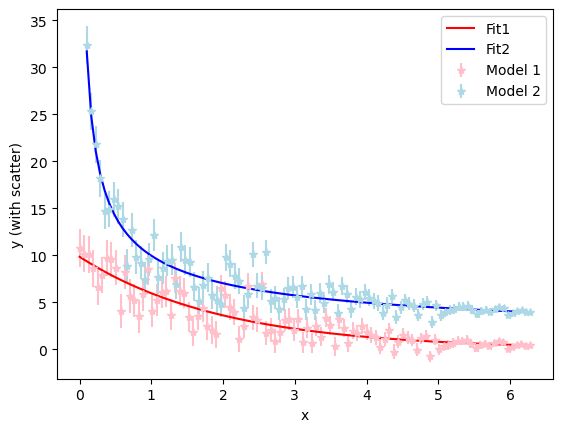

In [226]:
y1 = model1(x1, 10, 0.5) # Equation for  model 1
y2 = model2(x2, 10, 0.5) # Equation for model 2



### Making scatter
sigmas = np.linspace(2, 0.2, 100)
scatter = np.random.normal(loc=0, scale=sigmas, size=100)
y1_new = y1 + scatter
y2_new = y2 + scatter

plt.errorbar(x1, y1_new, yerr=sigmas, fmt='*', color='pink', label='Model 1')
plt.errorbar(x2, y2_new, yerr=sigmas, fmt='*', color='lightblue', label='Model 2')



###Making best fit lines
params1, params_cov1 = curve_fit(model1, x1, y1_new, sigma=sigmas) 
a_fit1 = params1[0]
b_fit1 = params1[1]

params2, params_cov2 = curve_fit(model2, x2, y2_new, sigma=sigmas) 
a_fit2 = params2[0]
b_fit2 = params2[1]

y_fit1 = model1(x1, a_fit1, b_fit1) 
y_fit2 = model2(x2, a_fit2, b_fit2)

plt.plot(x1, y_fit1, label="Fit1", color='red')
plt.plot(x2, y_fit2, label="Fit2", color='blue')



### Labels
plt.xlabel('x')
plt.ylabel('y (with scatter)')
plt.legend(loc=1)


plt.savefig('prompt3_plot.pdf', bbox_inches='tight', dpi=600)
print(f'The true value of the line for Module 1 was a = 10, b = 0.5. Curve_fit found a = {a_fit1:.4f}, b = {b_fit1:.4f}')
print(f'The true value of the line for Molule 2 was a = 10, b = 0.5. Curve_fit found a = {a_fit2:.4f}, b = {b_fit2:.4f}')